# Exploratory Data Analysis (EDA)

## Network Intrusion Detection Using Machine Learning

This notebook performs Exploratory Data Analysis (EDA) on the CIC-IDS2017 network intrusion detection dataset.

The main objectives of this analysis are:

- Understand the structure and characteristics of the dataset.
- Identify the number of observations and features.
- Examine data types and statistical properties.
- Analyze the target variable and class distribution.
- Detect missing and duplicate values.
- Explore numerical and categorical features.
- Visualize feature distributions.
- Detect potential outliers.
- Analyze relationships between numerical features using correlation analysis.

The findings from this EDA will be used to design the data preprocessing pipeline in the next stage of the project.


# 01_EDA — Exploratory Data Analysis

```text
01_EDA
│
├── Introduction
├── Import Libraries
├── Load Dataset
├── Dataset Dimensions
├── Column Analysis
├── Dataset Information
├── Data Types
├── Statistical Summary
│
├── Target Analysis
│   ├── Classes
│   ├── Counts
│   └── Distribution Graph
│
├── Data Quality
│   ├── Missing Values
│   └── Duplicates
│
├── Feature Analysis
│   ├── Numerical Features
│   ├── Categorical Features
│   ├── Cardinality
│   ├── Histograms
│   └── Skewness
│
├── Outlier Analysis
│   ├── Boxplots
│   ├── IQR
│   ├── Outlier Count
│   └── Outlier Percentage
│
├── Correlation Analysis
│   ├── Correlation Matrix
│   ├── Heatmap
│   └── Highly Correlated Pairs
│
└── EDA Summary

## 1. Import Required Libraries

The following Python libraries are used for data manipulation, numerical analysis, visualization, and exploratory analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load the Dataset

The CIC-IDS2017 dataset is stored in the `data` directory of the project.

Since this notebook is located inside the `notebooks` directory, the dataset is accessed using the relative path `/Users/kasturi/Desktop/Network-Intrusion-Detection/data/CIC_IDS2017.csv`.

In [11]:
df = pd.read_csv("/Users/kasturi/Desktop/Network-Intrusion-Detection/data/CIC_IDS2017.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


## 3. Determine the Dimensions of the Dataset

The shape of a dataset represents:

- **Rows:** Number of observations or network traffic records.
- **Columns:** Number of variables or features available for each observation.

Understanding the dataset dimensions provides an initial overview of its size.

In [13]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 1233163
Number of Columns: 79


In [14]:
df.shape

(1233163, 79)

## 4. Display the First Five Records

The first five rows are displayed to verify that the dataset has been loaded correctly and to obtain an initial understanding of the structure and values of the features.

In [15]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,3000000.0,5.000000e+05,4.0,0.0,4,4,4,4.0,0.0,4,4,0,0.0,0.0,0,0,0,0,0,0,40,0,5.000000e+05,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,12000000.0,2.000000e+06,1.0,0.0,1,1,1,1.0,0.0,1,1,0,0.0,0.0,0,0,0,0,0,0,40,0,2.000000e+06,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,12000000.0,2.000000e+06,1.0,0.0,1,1,1,1.0,0.0,1,1,0,0.0,0.0,0,0,0,0,0,0,40,0,2.000000e+06,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,12000000.0,2.000000e+06,1.0,0.0,1,1,1,1.0,0.0,1,1,0,0.0,0.0,0,0,0,0,0,0,40,0,2.000000e+06,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4000000.0,6.666667e+05,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,6.666667e+05,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,245,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


## 5. Display the Last Five Records

The last five records are examined to verify the end of the dataset and ensure that the complete file has been loaded successfully.

In [16]:
df.tail()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
1233158,61374,61,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,196721.3115,32786.88525,61.0,0.0,61,61,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,16393.44262,16393.44262,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,288,253,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1233159,61378,72,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,166666.6667,27777.77778,72.0,0.0,72,72,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,13888.88889,13888.88889,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,288,253,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1233160,61375,75,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,160000.0000,26666.66667,75.0,0.0,75,75,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,13333.33333,13333.33333,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,288,253,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1233161,61323,48,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,250000.0000,41666.66667,48.0,0.0,48,48,48,48.0,0.0,48,48,0,0.0,0.0,0,0,0,0,0,0,40,0,41666.66667,0.00000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,4719,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1233162,61326,68,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,176470.5882,29411.76471,68.0,0.0,68,68,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,14705.88235,14705.88235,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,13140,64240,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


## 6. Examine the Column Names

The column names represent the network traffic features and the target variable.

The raw CIC-IDS2017 dataset may contain leading or trailing whitespace in some column names. These names are intentionally examined in their original form during EDA. Column-name cleaning will be performed later during preprocessing.

In [17]:
df.columns

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

### Why `repr()`?

`repr()` is useful here because it shows the raw string, including leading or trailing spaces.

For example:

`'Destination Port'`

clearly shows that there is a space before `Destination Port`.

This helps us understand the raw dataset before cleaning the column names.

In [18]:
print("Total number of columns:", len(df.columns))

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {repr(column)}")

Total number of columns: 79
1. ' Destination Port'
2. ' Flow Duration'
3. ' Total Fwd Packets'
4. ' Total Backward Packets'
5. 'Total Length of Fwd Packets'
6. ' Total Length of Bwd Packets'
7. ' Fwd Packet Length Max'
8. ' Fwd Packet Length Min'
9. ' Fwd Packet Length Mean'
10. ' Fwd Packet Length Std'
11. 'Bwd Packet Length Max'
12. ' Bwd Packet Length Min'
13. ' Bwd Packet Length Mean'
14. ' Bwd Packet Length Std'
15. 'Flow Bytes/s'
16. ' Flow Packets/s'
17. ' Flow IAT Mean'
18. ' Flow IAT Std'
19. ' Flow IAT Max'
20. ' Flow IAT Min'
21. 'Fwd IAT Total'
22. ' Fwd IAT Mean'
23. ' Fwd IAT Std'
24. ' Fwd IAT Max'
25. ' Fwd IAT Min'
26. 'Bwd IAT Total'
27. ' Bwd IAT Mean'
28. ' Bwd IAT Std'
29. ' Bwd IAT Max'
30. ' Bwd IAT Min'
31. 'Fwd PSH Flags'
32. ' Bwd PSH Flags'
33. ' Fwd URG Flags'
34. ' Bwd URG Flags'
35. ' Fwd Header Length'
36. ' Bwd Header Length'
37. 'Fwd Packets/s'
38. ' Bwd Packets/s'
39. ' Min Packet Length'
40. ' Max Packet Length'
41. ' Packet Length Mean'
42. ' Packet 

## 7. Examine the Dataset Information

The `info()` method provides important information about the dataset, including:

- Column names
- Number of non-null values
- Data types
- Memory usage

This helps identify numerical and categorical variables and provides an initial indication of missing data.

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1233163 entries, 0 to 1233162
Data columns (total 79 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0    Destination Port             1233163 non-null  int64  
 1    Flow Duration                1233163 non-null  int64  
 2    Total Fwd Packets            1233163 non-null  int64  
 3    Total Backward Packets       1233163 non-null  int64  
 4   Total Length of Fwd Packets   1233163 non-null  int64  
 5    Total Length of Bwd Packets  1233163 non-null  int64  
 6    Fwd Packet Length Max        1233163 non-null  int64  
 7    Fwd Packet Length Min        1233163 non-null  int64  
 8    Fwd Packet Length Mean       1233163 non-null  float64
 9    Fwd Packet Length Std        1233163 non-null  float64
 10  Bwd Packet Length Max         1233163 non-null  int64  
 11   Bwd Packet Length Min        1233163 non-null  int64  
 12   Bwd Packet Length Mean       1233163 n

## 8. Analyze the Data Types

Understanding the data types of the features is important because different types of variables require different preprocessing techniques.

The dataset may contain numerical variables such as packet counts, durations, and lengths, along with a categorical target variable representing the traffic class.

In [20]:
df.dtypes.value_counts()

int64      54
float64    24
str         1
Name: count, dtype: int64

In [32]:
df.dtypes

 Destination Port                 int64
 Flow Duration                    int64
 Total Fwd Packets                int64
 Total Backward Packets           int64
Total Length of Fwd Packets       int64
 Total Length of Bwd Packets      int64
 Fwd Packet Length Max            int64
 Fwd Packet Length Min            int64
 Fwd Packet Length Mean         float64
 Fwd Packet Length Std          float64
Bwd Packet Length Max             int64
 Bwd Packet Length Min            int64
 Bwd Packet Length Mean         float64
 Bwd Packet Length Std          float64
Flow Bytes/s                    float64
 Flow Packets/s                 float64
 Flow IAT Mean                  float64
 Flow IAT Std                   float64
 Flow IAT Max                     int64
 Flow IAT Min                     int64
Fwd IAT Total                     int64
 Fwd IAT Mean                   float64
 Fwd IAT Std                    float64
 Fwd IAT Max                      int64
 Fwd IAT Min                      int64


## 9. Generate a Statistical Summary

Descriptive statistics are used to understand the distribution and numerical characteristics of the dataset.

The summary includes:

- Count
- Mean
- Standard deviation
- Minimum
- First quartile (25%)
- Median (50%)
- Third quartile (75%)
- Maximum

These statistics will also help us identify unusually large or small values that may require further investigation.

### Understanding `df.describe()`

`df.describe()` gives a quick statistical summary of the numerical columns in the dataset. It helps us understand the distribution and range of the data by showing the count, mean, standard deviation, minimum, quartiles, and maximum values.

This is useful during exploratory data analysis (EDA) to identify unusual values, differences in scale, and potential outliers.

In [21]:
df.describe()


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233052e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1233163.0,1233163.0,1233163.0,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1233163.0,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1233163.0,1233163.0,1233163.0,1233163.0,1233163.0,1233163.0,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06,1.233163e+06
mean,9.115093e+03,1.049132e+07,8.306129e+00,9.146779e+00,5.479333e+02,1.380869e+04,2.265081e+02,1.992463e+01,6.562331e+01,7.751810e+01,7.797963e+02,4.015786e+01,2.774006e+02,3.132321e+02,inf,inf,9.778285e+05,1.857375e+06,5.463543e+06,1.520718e+05,1.013922e+07,1.885462e+06,1.697708e+06,5.274853e+06,9.892404e+05,7.894671e+06,1.458245e+06,8.663014e+05,3.224099e+06,9.161683e+05,4.641560e-02,0.0,0.0,0.0,-5.581822e+03,-1.215476e+03,4.516397e+04,8.649468e+03,1.586066e+01,8.990599e+02,1.656646e+02,2.914840e+02,5.623720e+05,1.437523e-02,4.641560e-02,1.362350e-04,3.597205e-01,2.934235e-01,1.031113e-01,0.0,1.370460e-04,7.634376e-01,1.866925e+02,6.562331e+01,2.774006e+02,-5.581822e+03,0.0,0.0,0.0,0.0,0.0,0.0,8.306129e+00,5.479333e+02,9.146779e+00,1.380949e+04,8.219239e+03,2.022308e+03,5.792375e+00,-1.538615e+03,8.447901e+04,3.461024e+04,1.470829e+05,6.504221e+04,4.357289e+06,7.895401e+05,4.923131e+06,3.763799e+06
std,1.919186e+04,2.841065e+07,7.273630e+02,9.649392e+02,5.402942e+03,2.186062e+06,9.049776e+02,7.676291e+01,2.370115e+02,3.704081e+02,1.954606e+03,6.934057e+01,6.080510e+02,8.901653e+02,NaN,NaN,4.067820e+06,6.127984e+06,1.682847e+07,2.738828e+06,2.828264e+07,8.760679e+06,5.907097e+06,1.699536e+07,8.346342e+06,2.574063e+07,8.392673e+06,3.816347e+06,1.291158e+07,8.127289e+06,2.103835e-01,0.0,0.0,0.0,2.366009e+06,4.072514e+05,1.945232e+05,4.173493e+04,2.356902e+01,2.100461e+03,3.218631e+02,6.909986e+02,2.061667e+06,1.190319e-01,2.103835e-01,1.167119e-02,4.799186e-01,4.553310e-01,3.041043e-01,0.0,1.170587e-02,7.834597e-01,3.553189e+02,2.370115e+02,6.080510e+02,2.366009e+06,0.0,0.0,0.0,0.0,0.0,0.0,7.273630e+02,5.402942e+03,9.649392e+02,2.186212e+06,1.537997e+04,8.489683e+03,6.937981e+

### Understanding `df.describe().T`

`df.describe()` provides a statistical summary of the numerical columns in the dataset. It shows values such as:

- `count` – number of non-null values
- `mean` – average value
- `std` – standard deviation, showing how spread out the values are
- `min` – minimum value
- `25%` – first quartile
- `50%` – median
- `75%` – third quartile
- `max` – maximum value

The `.T` transposes the output, so each feature/column is displayed as a row. This makes it easier to compare the statistics of different features.

In [22]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Destination Port,1233163.0,9.115093e+03,1.919186e+04,0.000000e+00,53.000000,80.000000,1.812000e+03,6.553500e+04
Flow Duration,1233163.0,1.049132e+07,2.841065e+07,-1.300000e+01,100.000000,31085.000000,1.213026e+06,1.200000e+08
Total Fwd Packets,1233163.0,8.306129e+00,7.273630e+02,1.000000e+00,1.000000,2.000000,4.000000e+00,2.197590e+05
Total Backward Packets,1233163.0,9.146779e+00,9.649392e+02,0.000000e+00,1.000000,2.000000,4.000000e+00,2.919220e+05
Total Length of Fwd Packets,1233163.0,5.479333e+02,5.402942e+03,0.000000e+00,6.000000,51.000000,9.800000e+01,1.323378e+06
Total Length of Bwd Packets,1233163.0,1.380869e+04,2.186062e+06,0.000000e+00,6.000000,108.000000,3.720000e+02,6.554530e+08
Fwd Packet Length Max,1233163.0,2.265081e+02,9.049776e+02,0.000000e+00,6.000000,32.000000,5.100000e+01,2.482000e+04
Fwd Packet Length Min,1233163.0,1.992463e+01,7.676291e+01,0.000000e+00,0.000000,6.000000,3.500000e+01,2.325000e+03
Fwd Packet Length Mean,1233163.0,6.562331e+01,2.370115e+02,0.000000e+00,6.000000,29.000000,4.700000e+01,5.940857e+03
Fwd Packet Length Std,1233163.0,7.751810e+01,3.704081e+02,0.000000e+00,0.000000,0.000000,1.026320e+01,7.125597e+03


## 10. Identify the Target Variable

The target variable represents the class of network traffic.

In the raw CIC-IDS2017 dataset, the target column is named `Label`.

The target variable will be analyzed separately because it represents the outcome that the machine learning model will eventually learn to predict.

In [24]:
[column for column in df.columns if "Label" in column]

[' Label']

In [25]:
target_column = [column for column in df.columns if "Label" in column][0]

print("Target column:", repr(target_column))

Target column: ' Label'


## 11. Examine the Target Variable

The unique values and frequency of each class are examined to understand the types of network traffic present in the dataset.

This analysis is important because intrusion detection datasets are often highly imbalanced, where some attack classes may contain significantly more records than others.

In [26]:
print("Unique target classes:")

df[target_column].unique()

Unique target classes:


<StringArray>
['BENIGN', 'Bot', 'PortScan', 'DDoS']
Length: 4, dtype: str

In [27]:
print("Number of unique classes:", df[target_column].nunique())

Number of unique classes: 4


In [28]:
df[target_column].value_counts()

 Label
BENIGN      944240
PortScan    158930
DDoS        128027
Bot           1966
Name: count, dtype: int64

## 12. Analyze the Target Class Distribution

The frequency and percentage distribution of each target class are calculated to determine whether the dataset is balanced or imbalanced.

Class imbalance is important in network intrusion detection because a model may become biased toward classes with a larger number of observations.

In [29]:
class_counts = df[target_column].value_counts()

print("Class Counts:")
print(class_counts)

Class Counts:
 Label
BENIGN      944240
PortScan    158930
DDoS        128027
Bot           1966
Name: count, dtype: int64


In [30]:
class_percentages = df[target_column].value_counts(normalize=True) * 100

print("Class Percentages:")
print(class_percentages.round(2))

Class Percentages:
 Label
BENIGN      76.57
PortScan    12.89
DDoS        10.38
Bot          0.16
Name: proportion, dtype: float64


## 13. Visualize the Target Class Distribution

A bar chart is used to visualize the number of observations belonging to each network traffic class.

This visualization makes class imbalance easier to identify.

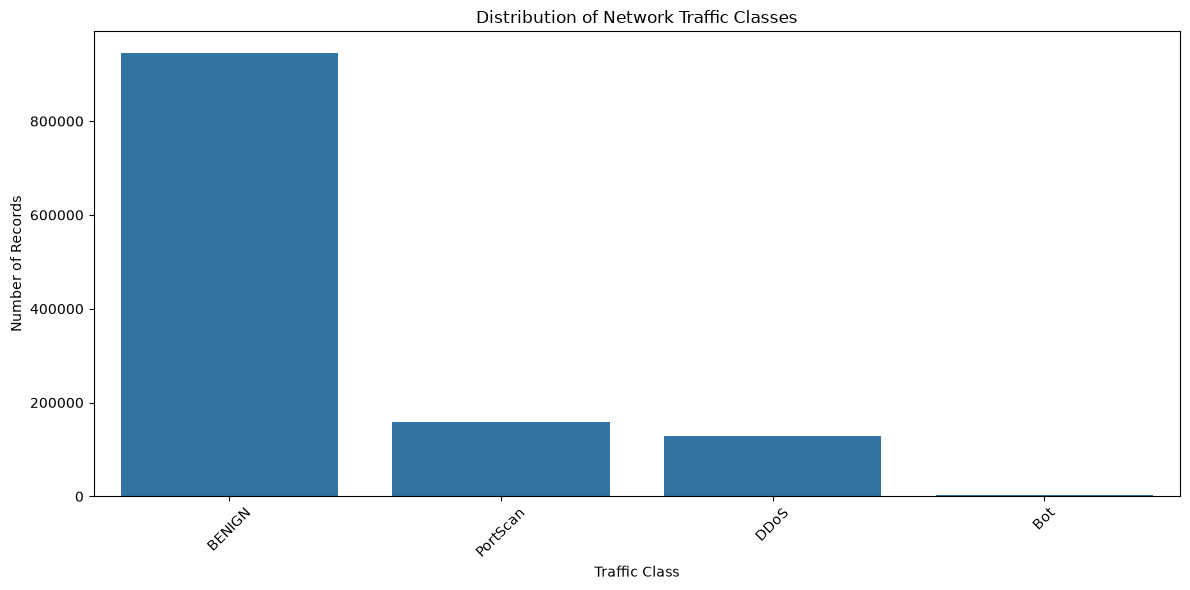

In [42]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x=target_column,
    order=df[target_column].value_counts().index
)

plt.title("Distribution of Network Traffic Classes")
plt.xlabel("Traffic Class")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 14. Analyze Missing Values

Missing values can affect statistical analysis and machine learning models.

The number and percentage of missing values are calculated for every feature. Only columns containing missing values will be displayed.

In [31]:
missing_count = df.isnull().sum()

missing_count = missing_count[
    missing_count > 0
].sort_values(ascending=False)

missing_count

Flow Bytes/s    111
dtype: int64

In [32]:
missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

missing_percentage = missing_percentage[
    missing_percentage > 0
].sort_values(ascending=False)

missing_percentage.round(2)

Flow Bytes/s    0.01
dtype: float64

## 15. Visualize Missing Values

A bar chart is generated only when missing values are present.

This visualization helps identify features that may require missing-value treatment during preprocessing.

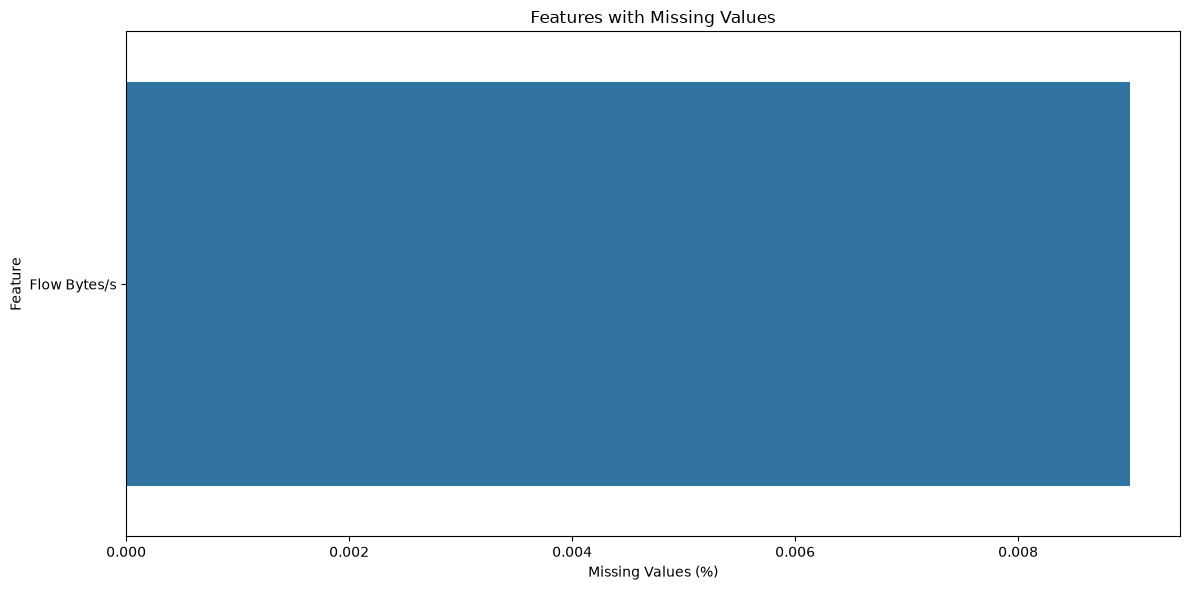

In [33]:
if len(missing_percentage) > 0:

    plt.figure(figsize=(12, 6))

    sns.barplot(
        x=missing_percentage.values,
        y=missing_percentage.index
    )

    plt.title("Features with Missing Values")
    plt.xlabel("Missing Values (%)")
    plt.ylabel("Feature")

    plt.tight_layout()
    plt.show()

else:
    print("No missing values found in the dataset.")

## 16. Detect Duplicate Records

Duplicate records are identified because repeated observations may affect statistical analysis and machine learning model performance.

The total number and percentage of duplicate rows are calculated.

In [34]:
duplicate_count = df.duplicated().sum()

duplicate_percentage = (
    duplicate_count / len(df)
) * 100

print("Number of duplicate rows:", duplicate_count)
print("Duplicate percentage:", round(duplicate_percentage, 2), "%")

Number of duplicate rows: 114482
Duplicate percentage: 9.28 %


## 17. Identify Numerical Features

Numerical features contain quantitative values that can be used for statistical analysis and visualization.

Identifying these features allows us to examine their distributions, ranges, and potential outliers.

In [35]:
numerical_features = df.select_dtypes(include=np.number).columns

print("Number of numerical features:", len(numerical_features))

print("\nNumerical features:")
for i, feature in enumerate(numerical_features, start=1):
    print(f"{i}. {feature}")

Number of numerical features: 78

Numerical features:
1.  Destination Port
2.  Flow Duration
3.  Total Fwd Packets
4.  Total Backward Packets
5. Total Length of Fwd Packets
6.  Total Length of Bwd Packets
7.  Fwd Packet Length Max
8.  Fwd Packet Length Min
9.  Fwd Packet Length Mean
10.  Fwd Packet Length Std
11. Bwd Packet Length Max
12.  Bwd Packet Length Min
13.  Bwd Packet Length Mean
14.  Bwd Packet Length Std
15. Flow Bytes/s
16.  Flow Packets/s
17.  Flow IAT Mean
18.  Flow IAT Std
19.  Flow IAT Max
20.  Flow IAT Min
21. Fwd IAT Total
22.  Fwd IAT Mean
23.  Fwd IAT Std
24.  Fwd IAT Max
25.  Fwd IAT Min
26. Bwd IAT Total
27.  Bwd IAT Mean
28.  Bwd IAT Std
29.  Bwd IAT Max
30.  Bwd IAT Min
31. Fwd PSH Flags
32.  Bwd PSH Flags
33.  Fwd URG Flags
34.  Bwd URG Flags
35.  Fwd Header Length
36.  Bwd Header Length
37. Fwd Packets/s
38.  Bwd Packets/s
39.  Min Packet Length
40.  Max Packet Length
41.  Packet Length Mean
42.  Packet Length Std
43.  Packet Length Variance
44. FIN Flag Count

## 18. Identify Categorical Features

Categorical features contain labels or categories rather than continuous numerical measurements.

These features are identified separately because they require different analysis and preprocessing techniques.

In [36]:
categorical_features = df.select_dtypes(include="object").columns

print("Number of categorical features:", len(categorical_features))

print("\nCategorical features:")
for i, feature in enumerate(categorical_features, start=1):
    print(f"{i}. {feature}")

Number of categorical features: 1

Categorical features:
1.  Label


## 19. Analyze Cardinality of Categorical Features

Cardinality represents the number of unique values present in a categorical feature.

This analysis helps determine how many categories are present and whether a feature contains a large number of unique values.

In [37]:
for feature in categorical_features:
    print(f"\nFeature: {feature}")
    print("Number of unique values:", df[feature].nunique())


Feature:  Label
Number of unique values: 4


## 20. Analyze the Most Frequent Values in Categorical Features

The frequency of values in categorical features is examined to understand the distribution of categories.

The target variable is particularly important because it represents the network traffic class.

In [38]:
for feature in categorical_features:
    print(f"\n{'=' * 60}")
    print(f"Feature: {feature}")
    print(f"{'=' * 60}")
    
    print(df[feature].value_counts().head(15))


Feature:  Label
 Label
BENIGN      944240
PortScan    158930
DDoS        128027
Bot           1966
Name: count, dtype: int64


## 21. Select Representative Numerical Features

The CIC-IDS2017 dataset contains many numerical network-traffic features.

To make the initial visual analysis readable, a representative group of features is selected. These features cover different characteristics of network traffic, including:

- Network ports
- Flow duration
- Packet counts
- Packet lengths
- Flow rates

Additional features will be investigated during the outlier and correlation analysis.

In [39]:
selected_features = [
    " Destination Port",
    " Flow Duration",
    " Total Fwd Packets",
    " Total Backward Packets",
    "Total Length of Fwd Packets",
    " Total Length of Bwd Packets",
    " Fwd Packet Length Mean",
    " Bwd Packet Length Mean"
]

print("Selected features:")

for feature in selected_features:
    print("-", feature)

Selected features:
-  Destination Port
-  Flow Duration
-  Total Fwd Packets
-  Total Backward Packets
- Total Length of Fwd Packets
-  Total Length of Bwd Packets
-  Fwd Packet Length Mean
-  Bwd Packet Length Mean


## 22. Analyze Numerical Feature Distributions

Histograms are used to examine the distribution of numerical features.

They help identify:

- Central tendency
- Spread
- Skewness
- Multiple peaks
- Extreme values

These observations will be useful when deciding which preprocessing techniques should be applied later.

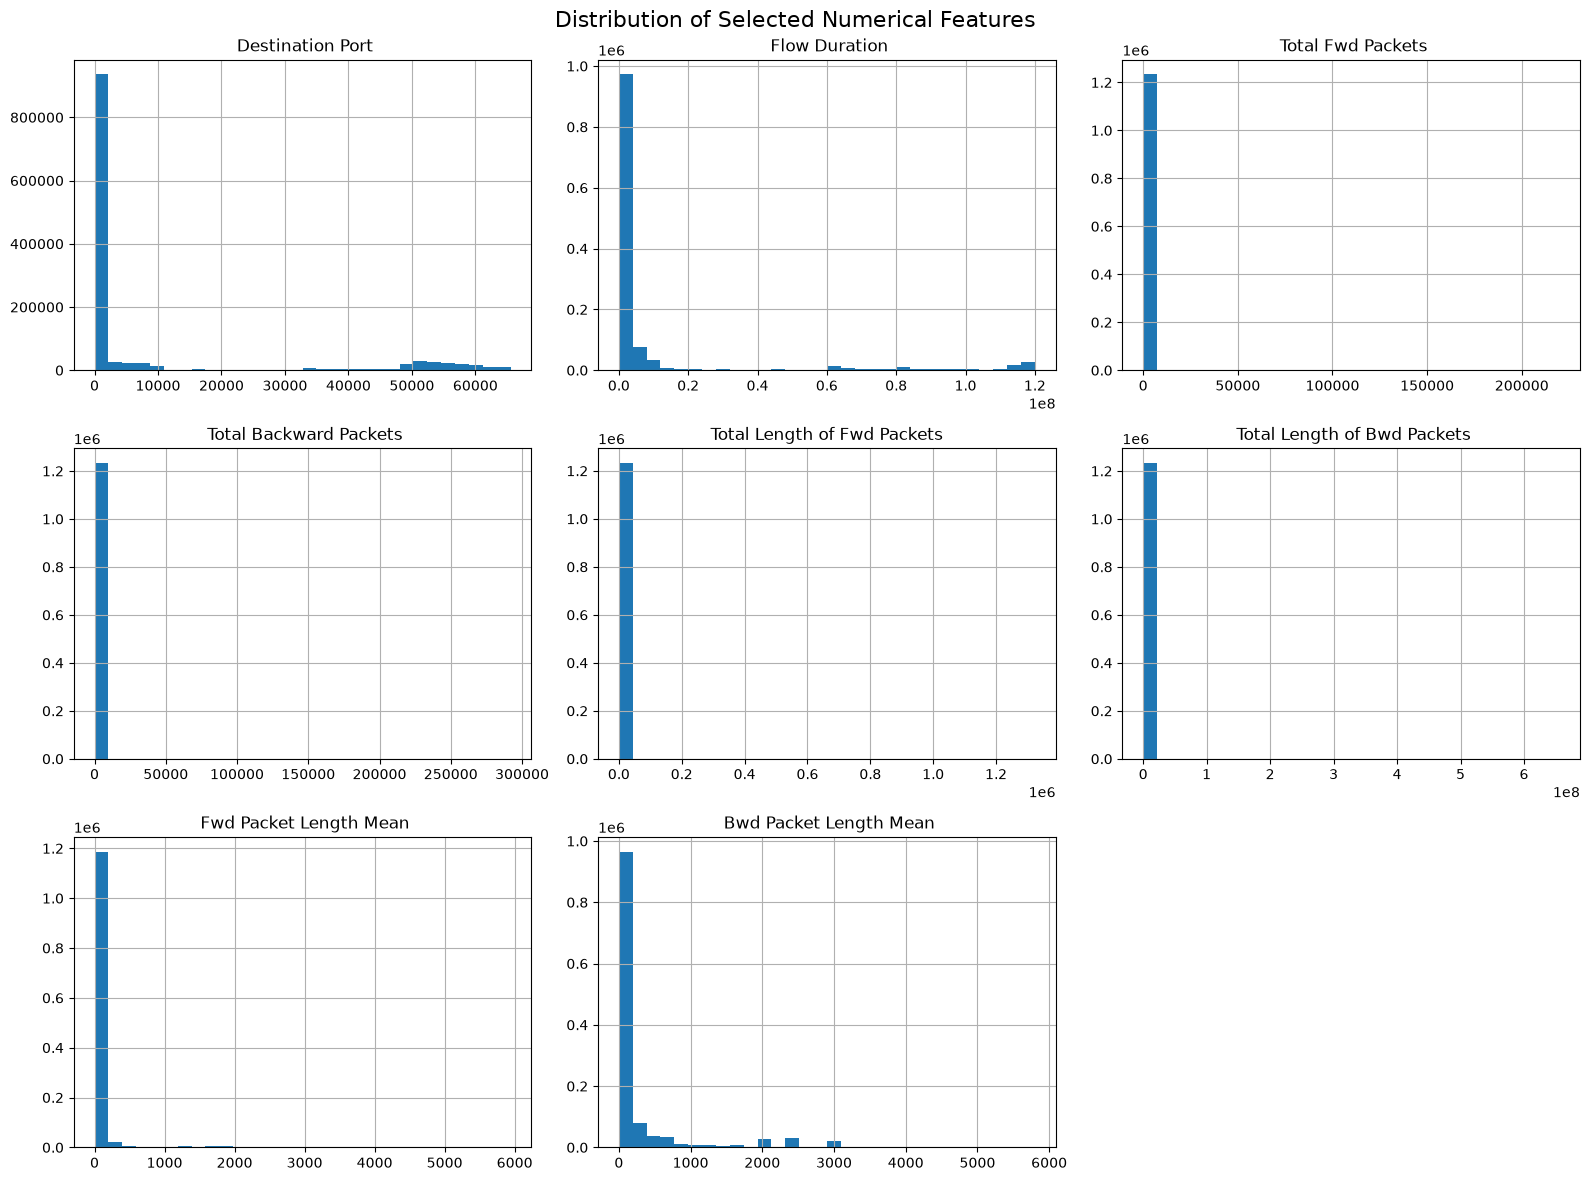

In [40]:
df[selected_features].hist(
    figsize=(16, 12),
    bins=30
)

plt.suptitle(
    "Distribution of Selected Numerical Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

## 24. Visualize Outliers Using Boxplots

Boxplots are used to visually identify the spread of numerical features and potential outliers.

A boxplot displays:

- Median
- First quartile (Q1)
- Third quartile (Q3)
- Interquartile range (IQR)
- Potential lower and upper outliers

Outliers detected during EDA will be investigated carefully before deciding how they should be handled during preprocessing.

## 23. Analyze Feature Skewness

Skewness measures the asymmetry of a numerical feature's distribution.

A value close to zero indicates a relatively symmetric distribution, while large positive or negative values indicate skewed distributions.

Highly skewed network traffic features may require special consideration during preprocessing.

In [42]:
skewness = df[numerical_features].skew()

skewness_df = pd.DataFrame({
    "Feature": skewness.index,
    "Skewness": skewness.values
})

skewness_df["Absolute_Skewness"] = (
    skewness_df["Skewness"].abs()
)

skewness_df = skewness_df.sort_values(
    "Absolute_Skewness",
    ascending=False
)

skewness_df.head(20)

,Feature,Skewness,Absolute_Skewness
55,Fwd Header Length.1,-615.413155,615.413155
34,Fwd Header Length,-615.413155,615.413155
35,Bwd Header Length,-318.867136,318.867136
68,act_data_pkt_fwd,272.004374,272.004374
3,Total Backward Packets,271.408612,271.408612
64,Subflow Bwd Packets,271.408612,271.408612
62,Subflow Fwd Packets,270.335726,270.335726
2,Total Fwd Packets,270.335726,270.335726
5,Total Length of Bwd Packets,269.192908,269.192908
65,Subflow Bwd Bytes,269.183353,269.183353


## 24. Visualize Outliers Using Boxplots

Boxplots are used to visually identify the spread of numerical features and potential outliers.

A boxplot displays:

- Median
- First quartile (Q1)
- Third quartile (Q3)
- Interquartile range (IQR)
- Potential lower and upper outliers

Outliers detected during EDA will be investigated carefully before deciding how they should be handled during preprocessing.

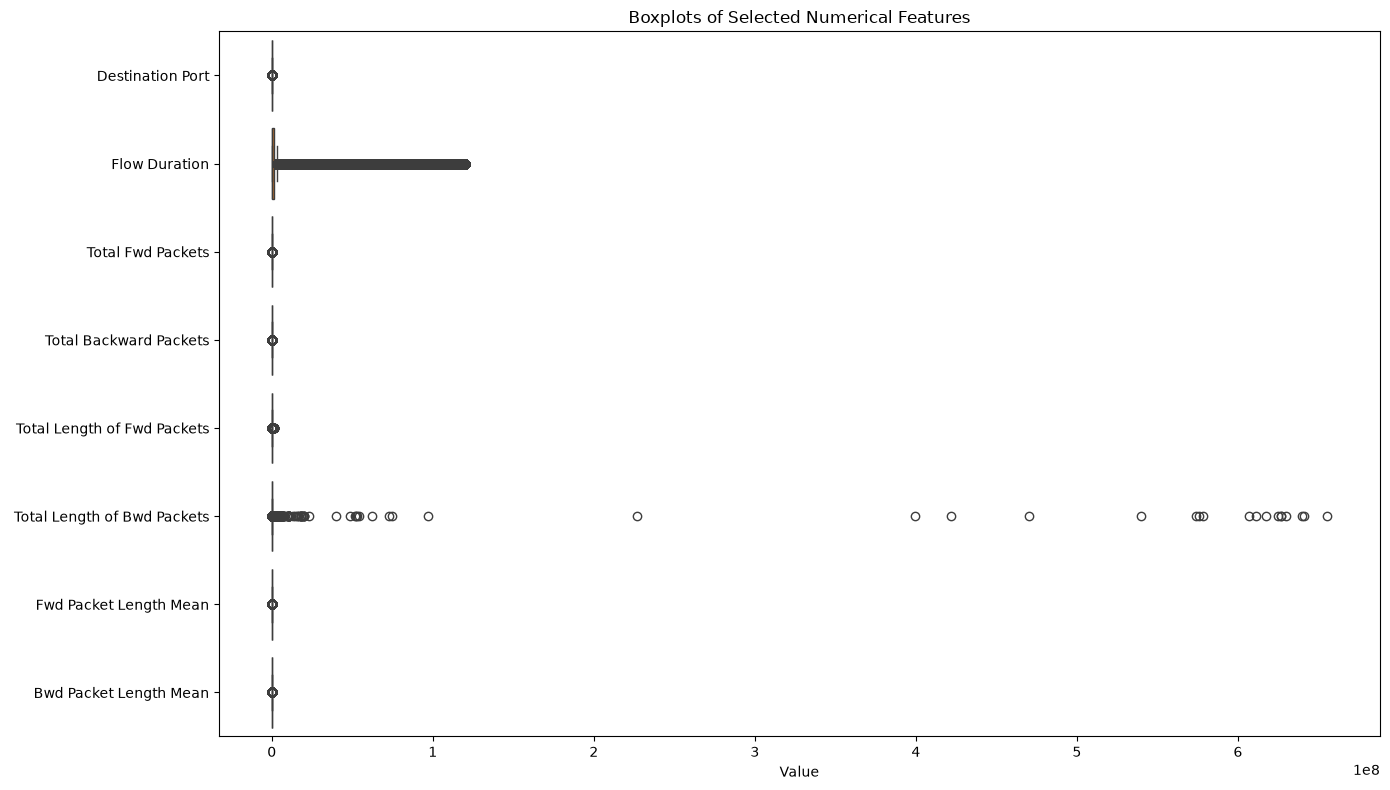

In [41]:
plt.figure(figsize=(14, 8))

sns.boxplot(
    data=df[selected_features],
    orient="h"
)

plt.title("Boxplots of Selected Numerical Features")
plt.xlabel("Value")

plt.tight_layout()
plt.show()

## 25. Individual Boxplot Analysis

Because features in network traffic data can have very different scales, individual boxplots are used to inspect selected features more clearly.

This allows potential extreme observations to be examined without the scale of other variables affecting the visualization.

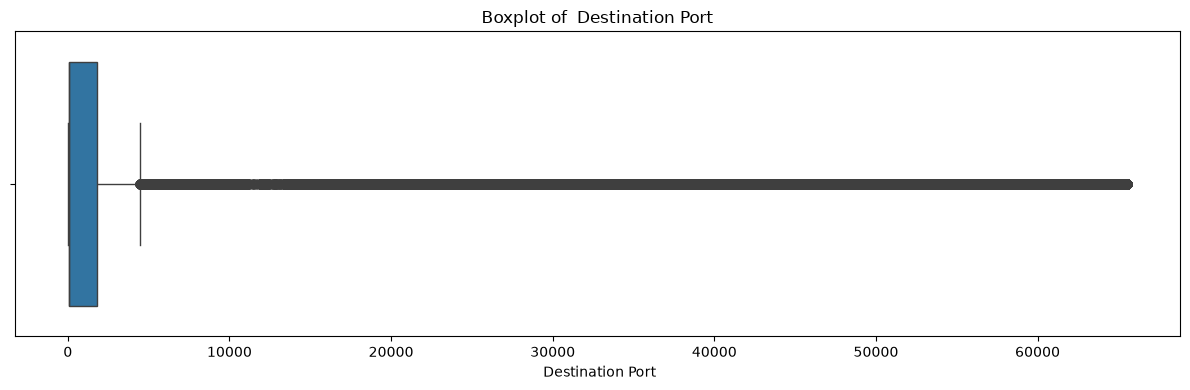

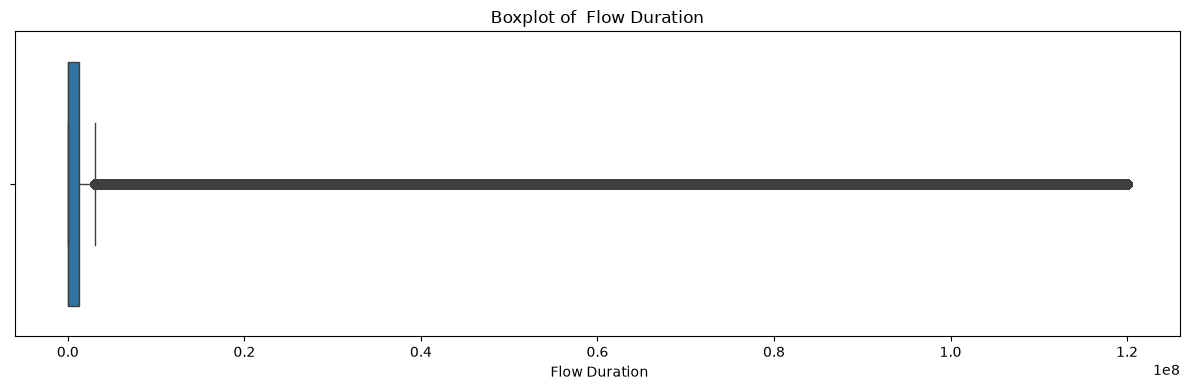

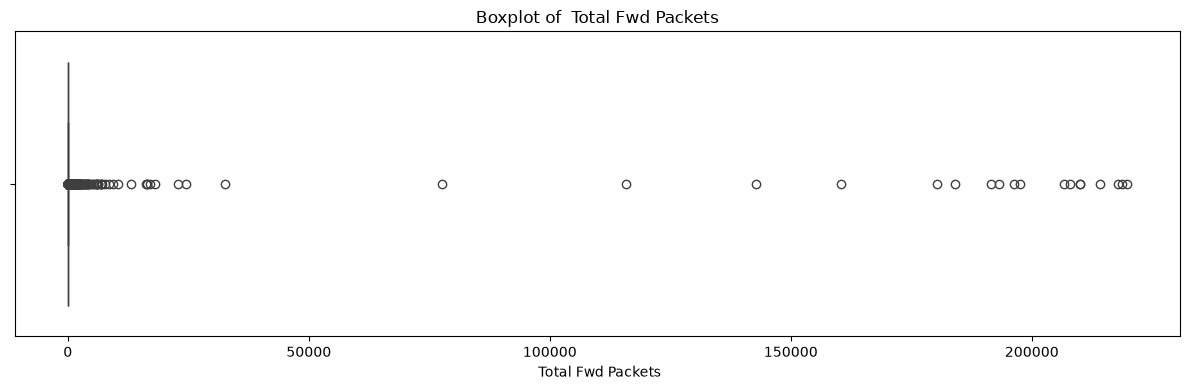

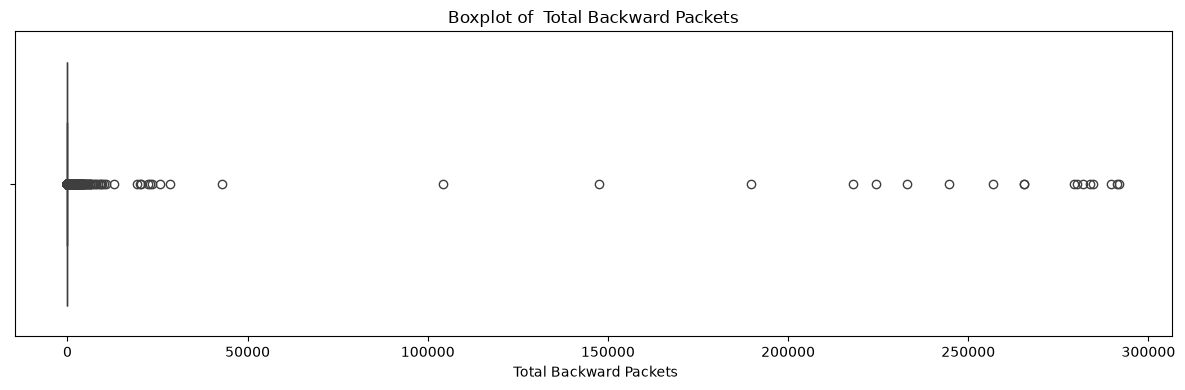

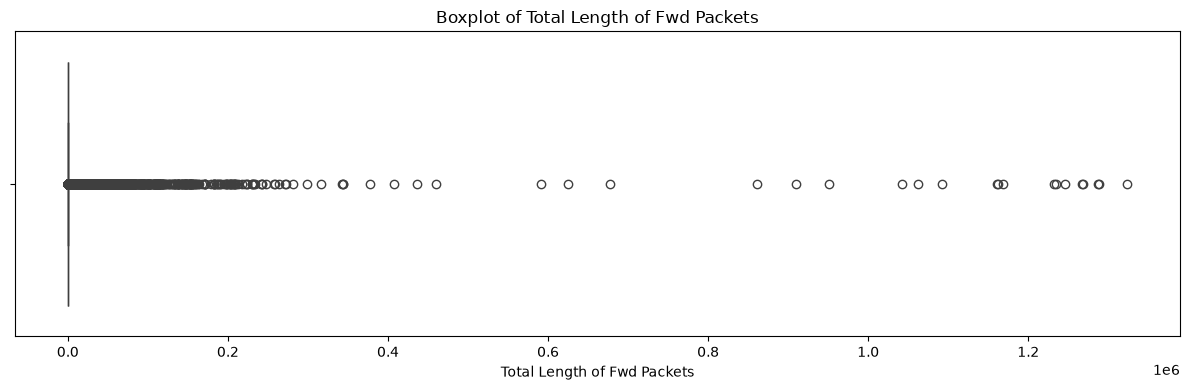

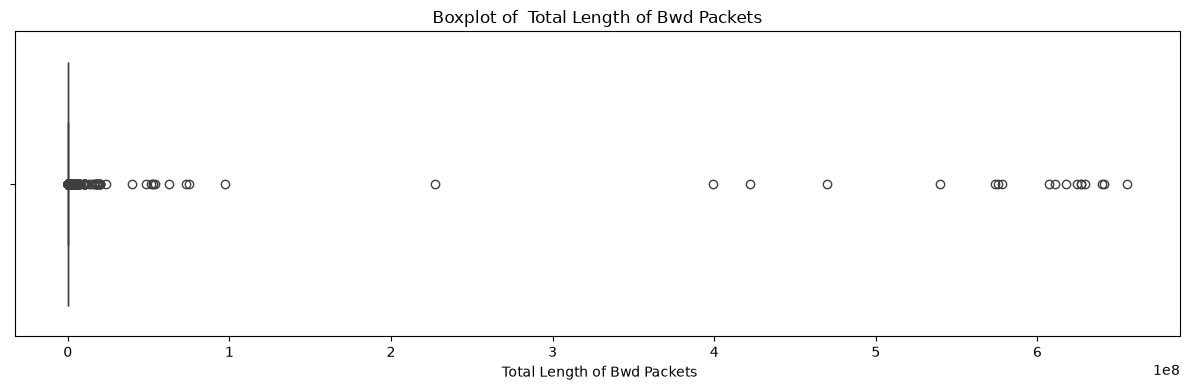

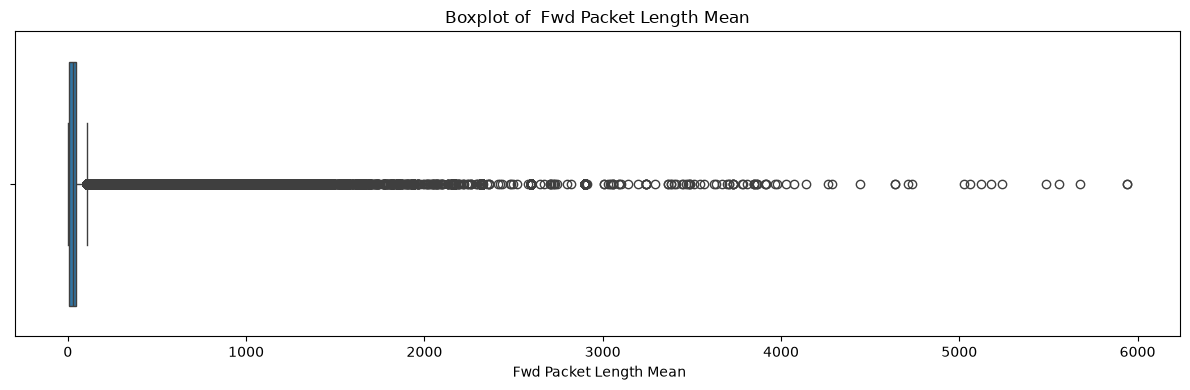

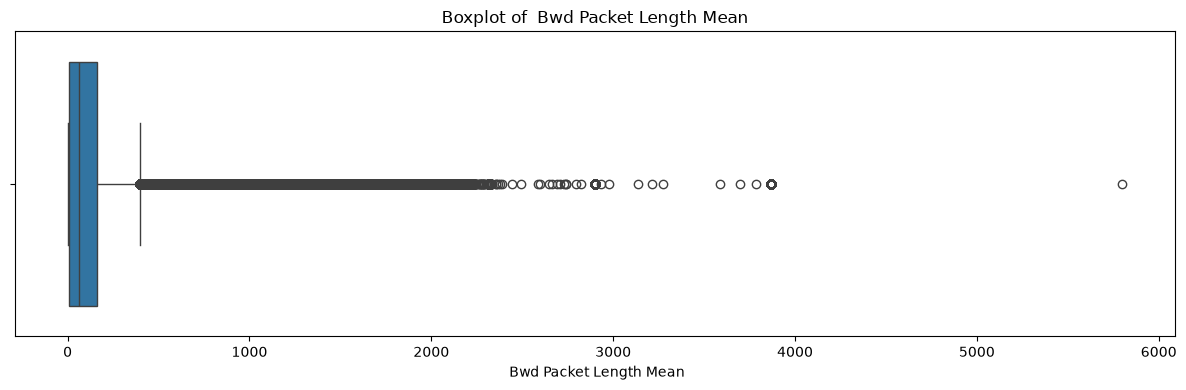

In [43]:
for feature in selected_features:

    plt.figure(figsize=(12, 4))

    sns.boxplot(x=df[feature])

    plt.title(f"Boxplot of {feature}")

    plt.xlabel(feature)

    plt.tight_layout()
    plt.show()

## 26. Individual Boxplot Analysis

Because the selected numerical features have different scales, individual boxplots are generated to examine each feature more clearly.

This visualization helps identify features that contain a large number of potential extreme observations.

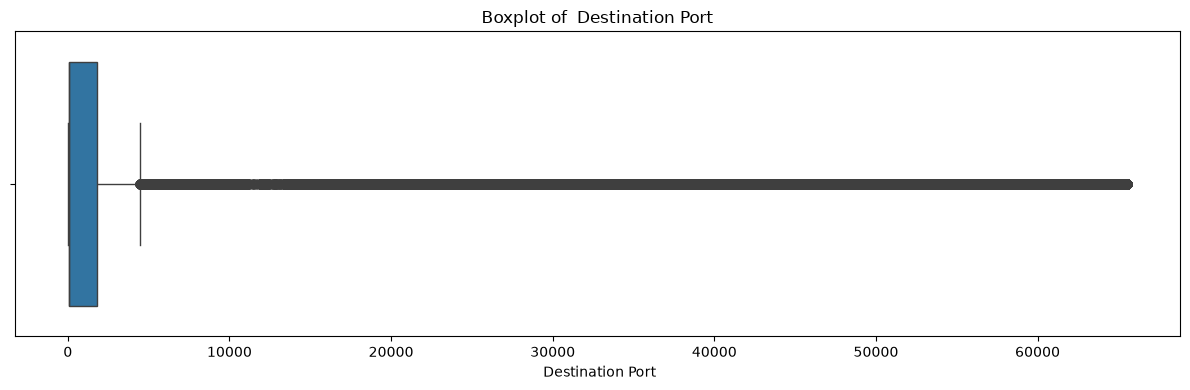

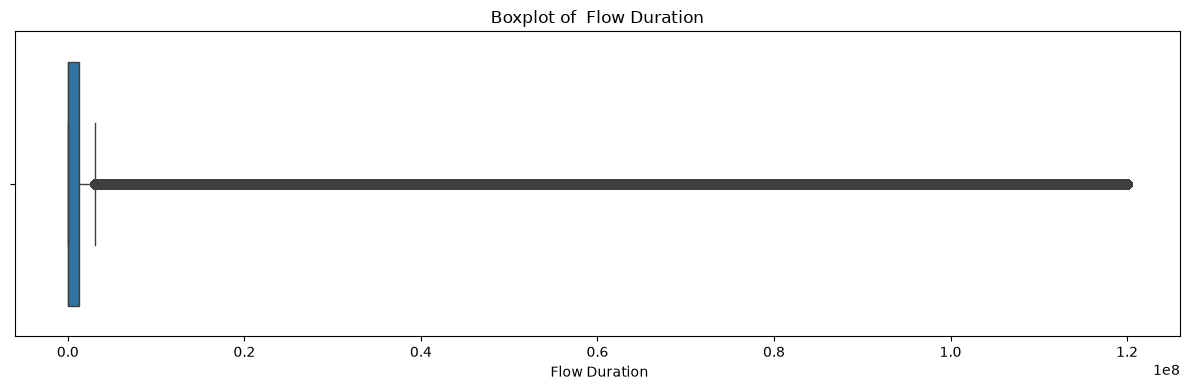

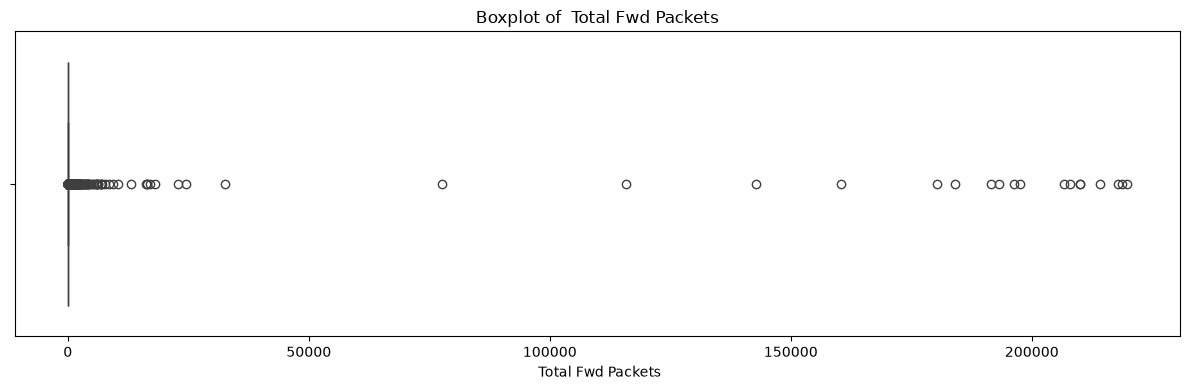

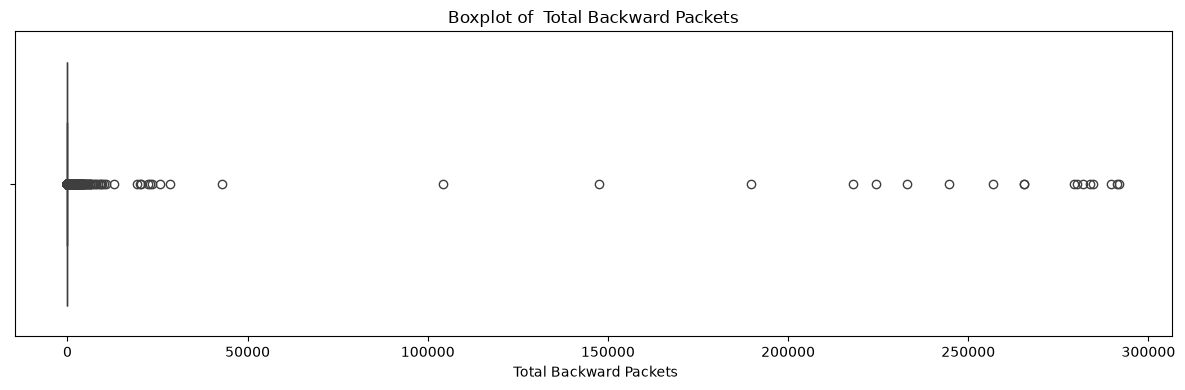

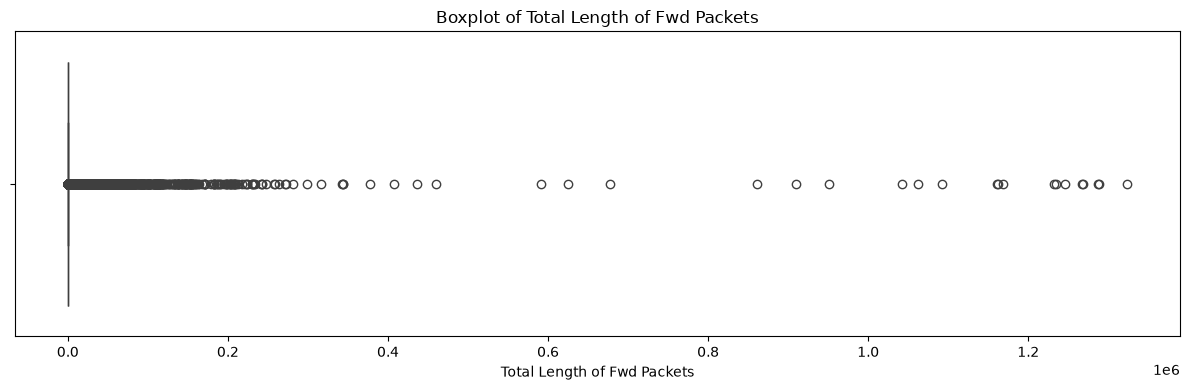

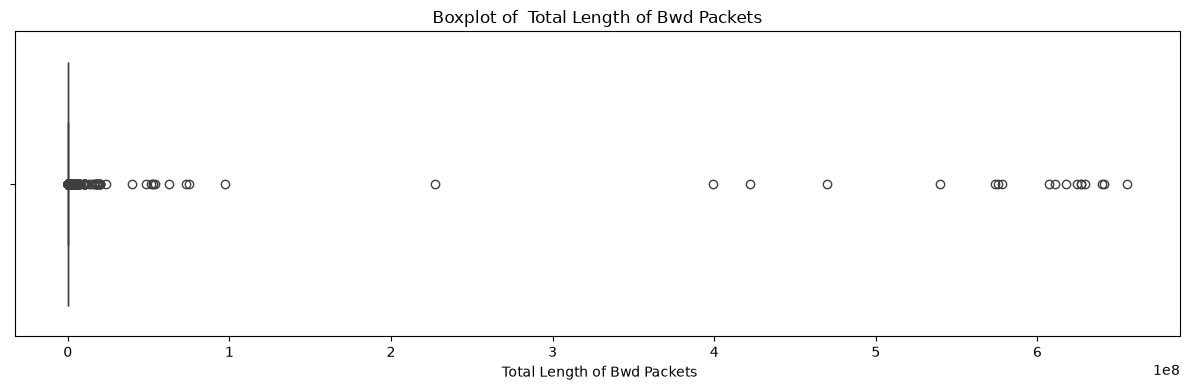

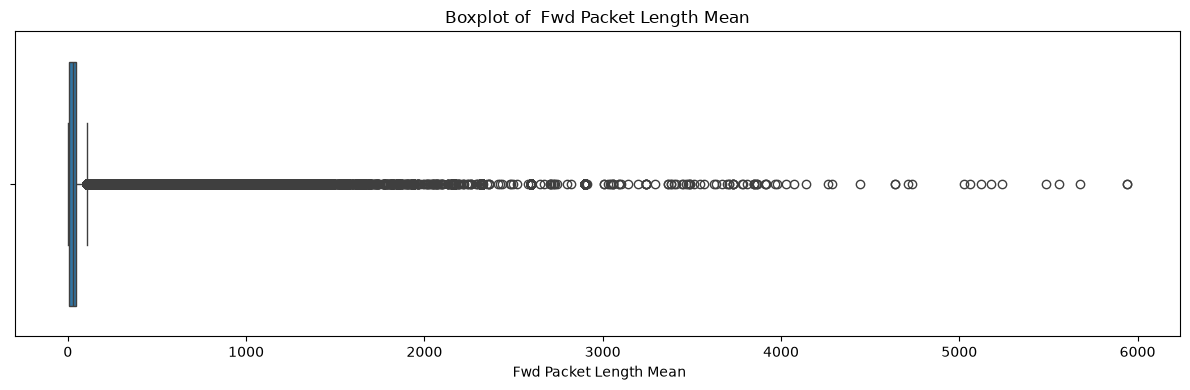

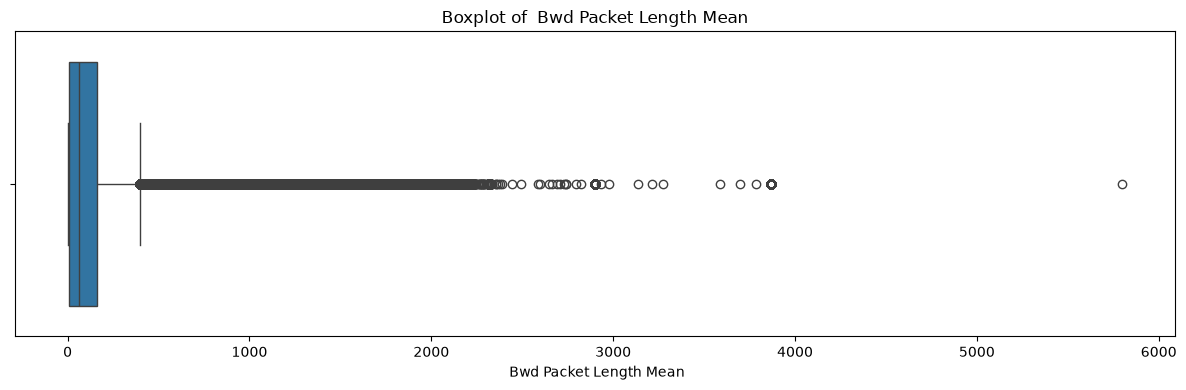

In [44]:
for feature in selected_features:

    plt.figure(figsize=(12, 4))

    sns.boxplot(
        x=df[feature]
    )

    plt.title(f"Boxplot of {feature}")
    plt.xlabel(feature)

    plt.tight_layout()
    plt.show()

## 27. Analyze Feature Ranges

The minimum and maximum values of selected numerical features are examined to understand their ranges.

Large differences between minimum and maximum values may indicate highly variable or skewed network traffic characteristics.

In [45]:
range_analysis = df[selected_features].agg(
    ["min", "max"]
).T

range_analysis["Range"] = (
    range_analysis["max"] - range_analysis["min"]
)

range_analysis.sort_values(
    "Range",
    ascending=False
)

,min,max,Range
Total Length of Bwd Packets,0.0,6.554530e+08,6.554530e+08
Flow Duration,-13.0,1.200000e+08,1.200000e+08
Total Length of Fwd Packets,0.0,1.323378e+06,1.323378e+06
Total Backward Packets,0.0,2.919220e+05,2.919220e+05
Total Fwd Packets,1.0,2.197590e+05,2.197580e+05
Destination Port,0.0,6.553500e+04,6.553500e+04
Fwd Packet Length Mean,0.0,5.940857e+03,5.940857e+03
Bwd Packet Length Mean,0.0,5.800500e+03,5.800500e+03


## 28. Identify Features with Zero Variance

A feature with the same value for every observation has zero variance and does not provide useful information for distinguishing between network traffic classes.

Such features may be candidates for removal during preprocessing.

In [46]:
zero_variance_features = []

for feature in numerical_features:

    if df[feature].nunique() <= 1:
        zero_variance_features.append(feature)

print("Number of zero-variance features:", len(zero_variance_features))

print("\nZero-variance features:")

if len(zero_variance_features) > 0:
    for feature in zero_variance_features:
        print("-", feature)
else:
    print("No zero-variance features found.")

Number of zero-variance features: 10

Zero-variance features:
-  Bwd PSH Flags
-  Fwd URG Flags
-  Bwd URG Flags
-  CWE Flag Count
- Fwd Avg Bytes/Bulk
-  Fwd Avg Packets/Bulk
-  Fwd Avg Bulk Rate
-  Bwd Avg Bytes/Bulk
-  Bwd Avg Packets/Bulk
- Bwd Avg Bulk Rate


## 29. EDA Observation: Extreme Values

The boxplots and feature-range analysis indicate that several numerical network traffic features may contain extreme values.

However, an extreme value is not automatically an erroneous value. In a network intrusion detection dataset, unusually large or small values may represent genuine characteristics of attack traffic.

Therefore, potential outliers will be quantified using the Interquartile Range (IQR) method before any decision is made about outlier treatment.

## 30. Detect Potential Outliers Using the IQR Method

The Interquartile Range (IQR) method is used to quantitatively identify potential outliers in numerical features.

The IQR is calculated as:

$$
IQR = Q3 - Q1
$$

where:

- **Q1** is the 25th percentile.
- **Q3** is the 75th percentile.

The lower and upper boundaries are calculated as:

$$
Lower\ Bound = Q1 - 1.5 \times IQR
$$

$$
Upper\ Bound = Q3 + 1.5 \times IQR
$$

Observations outside these boundaries are considered potential outliers.

These observations will only be identified at this stage. They will not be removed automatically.

In [47]:
skewness = df[numerical_features].skew()

skewness_df = pd.DataFrame({
    "Feature": skewness.index,
    "Skewness": skewness.values
})

skewness_df["Absolute_Skewness"] = (
    skewness_df["Skewness"].abs()
)

skewness_df = skewness_df.sort_values(
    "Absolute_Skewness",
    ascending=False
)

skewness_df.head(20)

,Feature,Skewness,Absolute_Skewness
55,Fwd Header Length.1,-615.413155,615.413155
34,Fwd Header Length,-615.413155,615.413155
35,Bwd Header Length,-318.867136,318.867136
68,act_data_pkt_fwd,272.004374,272.004374
3,Total Backward Packets,271.408612,271.408612
64,Subflow Bwd Packets,271.408612,271.408612
62,Subflow Fwd Packets,270.335726,270.335726
2,Total Fwd Packets,270.335726,270.335726
5,Total Length of Bwd Packets,269.192908,269.192908
65,Subflow Bwd Bytes,269.183353,269.183353


## 31. Test the IQR Outlier Detection Method

The IQR-based outlier detection function is first tested on the `Flow Duration` feature.

This provides an example of how the number of potential outliers and the calculated boundaries can be obtained for an individual feature.

In [50]:
def detect_outliers_iqr(data, column):
    
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]
    
    return len(outliers), lower_bound, upper_bound

In [51]:
feature = " Flow Duration"

outlier_count, lower_bound, upper_bound = detect_outliers_iqr(
    df,
    feature
)

print("Feature:", feature)
print("Number of potential outliers:", outlier_count)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Feature:  Flow Duration
Number of potential outliers: 271060
Lower bound: -1819288.25
Upper bound: 3032413.75


## 32. Calculate Potential Outliers for All Numerical Features

The IQR method is now applied to every numerical feature.

For each feature, the following information is recorded:

- Number of potential outliers
- Percentage of potential outliers
- Lower IQR boundary
- Upper IQR boundary

This provides a complete overview of the potential outlier distribution in the dataset.

In [52]:
outlier_summary = []

for feature in numerical_features:
    
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_mask = (
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    )
    
    outlier_count = outlier_mask.sum()
    
    outlier_percentage = (
        outlier_count / len(df)
    ) * 100
    
    outlier_summary.append({
        "Feature": feature,
        "Outlier_Count": outlier_count,
        "Outlier_Percentage": outlier_percentage,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df = outlier_df.sort_values(
    "Outlier_Count",
    ascending=False
)

outlier_df.head(20)

,Feature,Outlier_Count,Outlier_Percentage,Lower_Bound,Upper_Bound
13,Bwd Packet Length Std,296583,24.050592,-1.484924e+01,2.474874e+01
23,Fwd IAT Max,282185,22.883025,-1.776585e+05,2.960975e+05
20,Fwd IAT Total,280147,22.717759,-3.901358e+05,6.502262e+05
21,Fwd IAT Mean,279123,22.634721,-6.665023e+04,1.110837e+05
29,Bwd IAT Min,276486,22.420880,-6.000000e+00,1.000000e+01
42,Packet Length Variance,274570,22.265507,-2.780220e+04,4.635121e+04
17,Flow IAT Std,271777,22.039017,-4.563330e+05,7.605551e+05
18,Flow IAT Max,271487,22.015500,-1.535281e+06,2.559057e+06
22,Fwd IAT Std,271091,21.983387,-3.454023e+04,5.756704e+04
1,Flow Duration,271060,21.980874,-1.819288e+06,3.032414e+06


## 33. Examine the Potential Outlier Summary

The potential outlier summary is examined to identify numerical features with the largest number of observations outside the IQR boundaries.

A high outlier percentage does not necessarily indicate incorrect data. In network intrusion detection, extreme traffic measurements may represent legitimate network behaviour or attack activity.

Therefore, these results will be used for further investigation rather than immediate removal.

In [53]:
outlier_df[
    [
        "Feature",
        "Outlier_Count",
        "Outlier_Percentage"
    ]
].head(20)

,Feature,Outlier_Count,Outlier_Percentage
13,Bwd Packet Length Std,296583,24.050592
23,Fwd IAT Max,282185,22.883025
20,Fwd IAT Total,280147,22.717759
21,Fwd IAT Mean,279123,22.634721
29,Bwd IAT Min,276486,22.420880
42,Packet Length Variance,274570,22.265507
17,Flow IAT Std,271777,22.039017
18,Flow IAT Max,271487,22.015500
22,Fwd IAT Std,271091,21.983387
1,Flow Duration,271060,21.980874


## 34. Visualize Features with the Highest Potential Outlier Percentages

The features with the highest percentage of potential outliers are visualized using a horizontal bar chart.

This visualization helps identify which features may require further investigation during preprocessing.

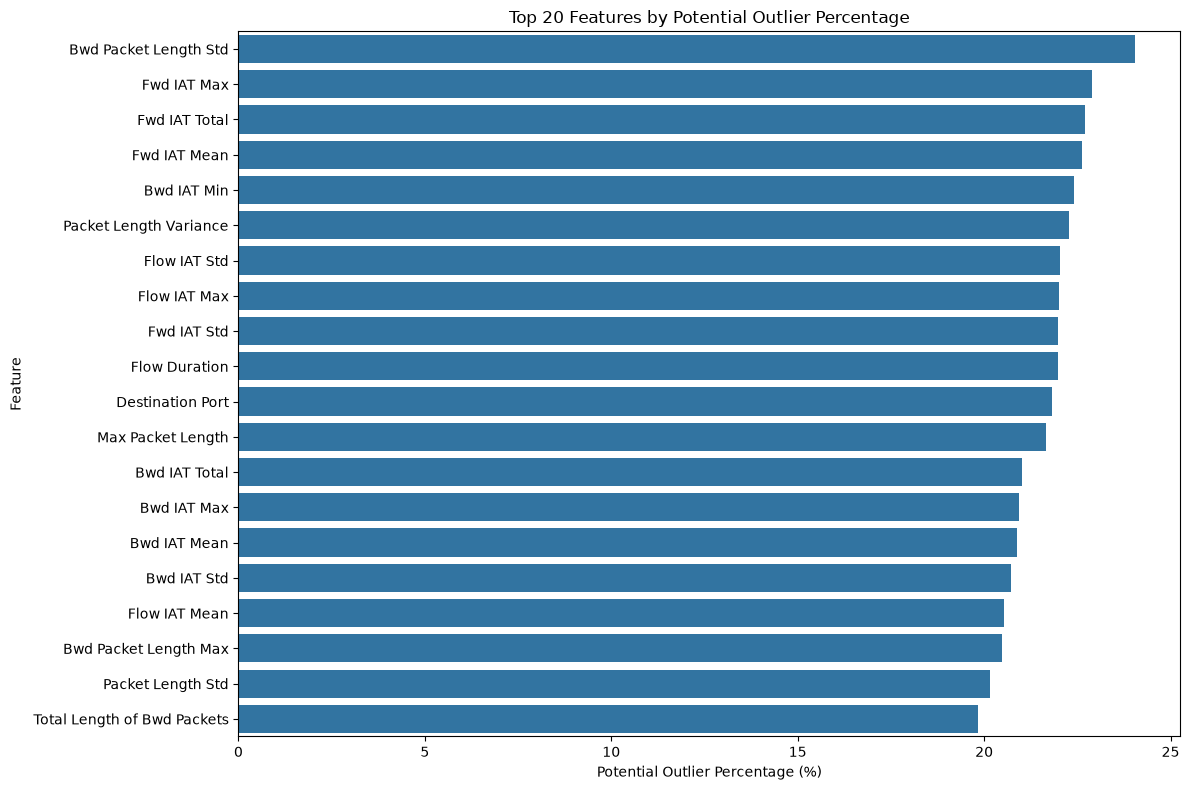

In [54]:
top_outlier_features = (
    outlier_df
    .sort_values(
        "Outlier_Percentage",
        ascending=False
    )
    .head(20)
)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_outlier_features,
    x="Outlier_Percentage",
    y="Feature"
)

plt.title(
    "Top 20 Features by Potential Outlier Percentage"
)

plt.xlabel("Potential Outlier Percentage (%)")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 35. Compare Outlier Counts and Percentages

Both the number and percentage of potential outliers are considered because features may have different distributions.

The outlier count shows the absolute number of observations identified as potential outliers, while the outlier percentage shows how large the outlier group is relative to the complete dataset.

In [55]:
outlier_df[
    [
        "Feature",
        "Outlier_Count",
        "Outlier_Percentage",
        "Lower_Bound",
        "Upper_Bound"
    ]
].head(20)

,Feature,Outlier_Count,Outlier_Percentage,Lower_Bound,Upper_Bound
13,Bwd Packet Length Std,296583,24.050592,-1.484924e+01,2.474874e+01
23,Fwd IAT Max,282185,22.883025,-1.776585e+05,2.960975e+05
20,Fwd IAT Total,280147,22.717759,-3.901358e+05,6.502262e+05
21,Fwd IAT Mean,279123,22.634721,-6.665023e+04,1.110837e+05
29,Bwd IAT Min,276486,22.420880,-6.000000e+00,1.000000e+01
42,Packet Length Variance,274570,22.265507,-2.780220e+04,4.635121e+04
17,Flow IAT Std,271777,22.039017,-4.563330e+05,7.605551e+05
18,Flow IAT Max,271487,22.015500,-1.535281e+06,2.559057e+06
22,Fwd IAT Std,271091,21.983387,-3.454023e+04,5.756704e+04
1,Flow Duration,271060,21.980874,-1.819288e+06,3.032414e+06


## 36. Important Observation About Outliers

The IQR method identifies observations that are statistically unusual relative to the distribution of each feature.

However, statistical outliers should not automatically be treated as errors.

In a network intrusion detection dataset, extreme values can contain meaningful information about unusual network activity and attacks.

Therefore, the outlier analysis will be used to guide preprocessing decisions rather than automatically deleting all detected observations.

## 37. Correlation Analysis

Correlation analysis is used to measure the strength and direction of the relationship between numerical features.

The Pearson correlation coefficient ranges from -1 to +1:

- **+1** indicates a strong positive relationship.
- **-1** indicates a strong negative relationship.
- **0** indicates little or no linear relationship.

Correlation analysis is useful for identifying redundant features and understanding relationships within the network traffic data.

In [56]:
# Calculate the correlation matrix for numerical features
correlation_matrix = df[numerical_features].corr()

# Display the correlation matrix
correlation_matrix.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
Destination Port,1.000000,-0.099057,-0.004054,-0.003637,0.039828,-0.002942,0.183516,0.008805,0.221860,0.206197,-0.184413,-0.253704,-0.209617,-0.163416,0.060749,0.297805,-0.069634,-0.054679,-0.039029,-0.023748,-0.101185,-0.058298,0.000079,-0.038604,-0.054146,-0.064098,-0.049374,0.069590,0.027868,-0.052280,0.261540,NaN,NaN,NaN,0.000865,0.001442,0.291470,0.109164,-0.265656,-0.070075,-0.111405,-0.071315,-0.035257,-0.030062,0.261540,-0.005104,-0.196553,0.564547,0.525855,NaN,-0.004990,0.105420,-0.112910,0.221860,-0.209617,0.000865,NaN,NaN,NaN,NaN,NaN,NaN,-0.004054,0.039828,-0.003637,-0.002942,-0.127931,0.234798,-0.003441,0.001932,-0.021312,-0.043550,-0.042378,-0.008862,-0.041099,0.033975,-0.028090,-0.052637
Flow Duration,-0.099057,1.000000,0.022797,0.021546,0.145938,0.017607,0.267614,-0.059306,0.179374,0.226759,0.259325,-0.158735,0.223573,0.210985,-0.020805,-0.096482,0.478654,0.653065,0.729182,0.077030,0.997607,0.489638,0.652818,0.727264,0.265813,0.900116,0.423292,0.562217,0.620292,0.262712,0.021056,NaN,NaN,NaN,-0.002738,-0.006188,-0.085736,-0.076524,-0.170860,0.308117,0.214355,0.237309,0.105121,-0.044272,0.021056,0.009727,0.174577,0.017476,-0.032736,NaN,0.009673,-0.134559,0.190976,0.179374,0.223573,-0.002738,NaN,NaN,NaN,NaN,NaN,NaN,0.022797,0.145938,0.021546,0.017607,0.108671,-0.002214,0.019777,-0.007491,0.259195,0.276386,0.364365,0.194323,0.712011,0.355855,0.721912,0.639212
Total Fwd Packets,-0.004054,0.022797,1.000000,0.999335,0.798477,0.998449,0.007677,-0.002241,0.000017,0.001043,0.018465,-0.004753,0.018856,0.005306,0.000482,-0.002171,-0.000611,0.000200,0.004482,-0.000484,0.022168,-0.000571,0.001332,0.003344,-0.001010,0.024520,-0.000377,0.002011,0.005577,-0.000889,0.001230,NaN,NaN,NaN,0.006110,0.047432,-0.001912,-0.001808,-0.005659,0.017215,0.020427,0.009590,0.003429,-0.001026,0.001230,0.000099,0.004833,0.001220,-0.003174,NaN,0.000098,-0.000315,0.018133,0.000017,0.018856,0.006110,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.798477,0.999335,0.998450,0.002955,-0.000408,0.998382,-0.000110,0.056650,0.008690,0.042213,0.059313,0.004636,0.000738,0.004338,0.004597
Total Backward Packets,-0.003637,0.021546,0.999335,1.000000,0.798250,0.996876,0.007517,-0.001810,-0.000093,0.000811,0.018447,-0.004144,0.019212,0.005242,0.000376,-0.002293,-0.000965,-0.000321,0.004002,-0.000522,0.020891,-0.000770,0.000591,0.002846,-0.000901,0.023901,-0.000492,0.001730,0.005722,-0.000819,0.000929,NaN,NaN,NaN,0.006452,0.047472,-0.002110,-0.001477,-0.005206,0.017176,0.021075,0.009722,0.003659,-0.001058,0.000929,0.000062,0.004620,0.000939,-0.002437,NaN,0.000061,0.002141,0.018782,-0.000093,0.019212,0.006452,NaN,NaN,NaN,NaN,NaN,NaN,0.999335,0.798250,1.000000,0.996878,0.002301,-0.000390,0.998155,0

## 38. Examine the Correlation Matrix

The correlation matrix contains the pairwise correlation coefficients between all numerical features.

Because the dataset contains many numerical features, the complete matrix may be difficult to interpret directly. A heatmap will therefore be used to visualize the relationships more clearly.

## 39. Generate a Correlation Heatmap

A heatmap provides a visual representation of the correlation matrix.

Strong positive correlations are represented by values closer to +1, while strong negative correlations are represented by values closer to -1.

The heatmap helps identify groups of highly correlated features that may contain overlapping information.

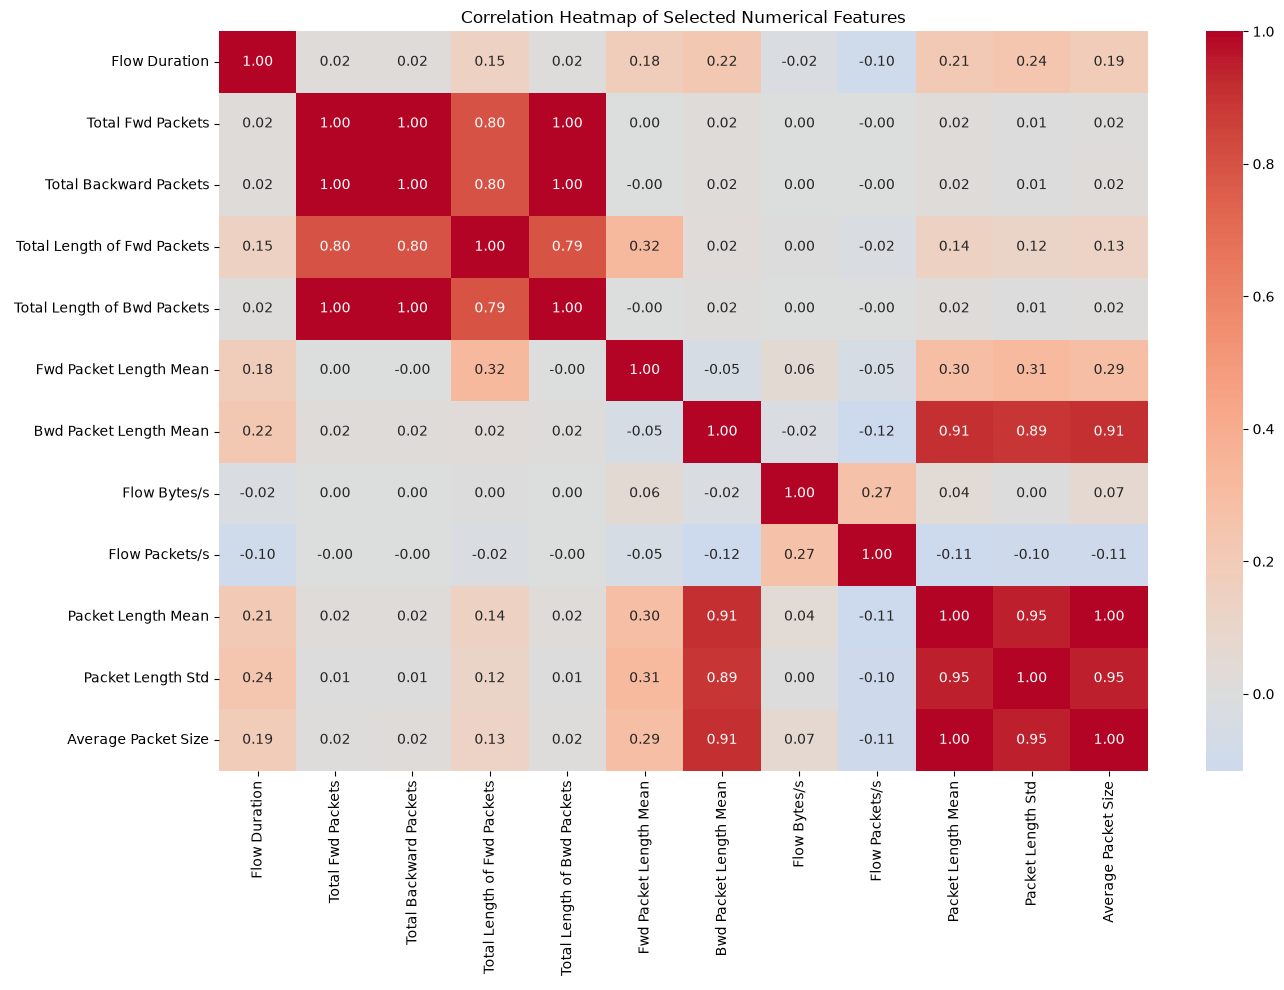

In [57]:
# Select representative numerical features
correlation_features = [
    " Flow Duration",
    " Total Fwd Packets",
    " Total Backward Packets",
    "Total Length of Fwd Packets",
    " Total Length of Bwd Packets",
    " Fwd Packet Length Mean",
    " Bwd Packet Length Mean",
    "Flow Bytes/s",
    " Flow Packets/s",
    " Packet Length Mean",
    " Packet Length Std",
    " Average Packet Size"
]

# Calculate correlation matrix
selected_correlation = df[
    correlation_features
].corr()

# Plot heatmap
plt.figure(figsize=(14, 10))

sns.heatmap(
    selected_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Selected Numerical Features")

plt.tight_layout()
plt.show()

## 40. Identify Highly Correlated Feature Pairs

Highly correlated features may contain similar information.

Feature pairs with an absolute correlation coefficient of 0.90 or greater are identified for further investigation.

These features will not be removed during EDA. The results will instead be considered during feature selection and preprocessing.

In [58]:
# Create a list to store highly correlated feature pairs
high_correlation_pairs = []

# Use the complete numerical correlation matrix
corr_matrix = df[numerical_features].corr()

# Compare each pair of numerical features
for i in range(len(corr_matrix.columns)):
    
    for j in range(i + 1, len(corr_matrix.columns)):
        
        correlation = corr_matrix.iloc[i, j]
        
        if abs(correlation) >= 0.90:
            
            high_correlation_pairs.append({
                "Feature_1": corr_matrix.columns[i],
                "Feature_2": corr_matrix.columns[j],
                "Correlation": correlation
            })

# Convert results into a DataFrame
high_corr_df = pd.DataFrame(high_correlation_pairs)

# Sort by absolute correlation
if len(high_corr_df) > 0:
    
    high_corr_df["Absolute_Correlation"] = (
        high_corr_df["Correlation"].abs()
    )
    
    high_corr_df = high_corr_df.sort_values(
        "Absolute_Correlation",
        ascending=False
    )
    
    high_corr_df.head(20)

else:
    print("No feature pairs with absolute correlation >= 0.90 were found.")

## 41. Display the Most Highly Correlated Feature Pairs

The strongest correlations are displayed to identify potentially redundant numerical features.

Highly correlated features may be considered for removal during preprocessing to reduce redundancy and improve model efficiency.

In [59]:
if len(high_corr_df) > 0:
    
    display(
        high_corr_df[
            [
                "Feature_1",
                "Feature_2",
                "Correlation"
            ]
        ].head(20)
    )

else:
    print("No highly correlated feature pairs found.")

,Feature_1,Feature_2,Correlation
4,Total Fwd Packets,Subflow Fwd Packets,1.000000
49,Fwd PSH Flags,SYN Flag Count,1.000000
50,Fwd Header Length,Fwd Header Length.1,1.000000
32,Bwd Packet Length Mean,Avg Bwd Segment Size,1.000000
22,Fwd Packet Length Mean,Avg Fwd Segment Size,1.000000
13,Total Length of Fwd Packets,Subflow Fwd Bytes,1.000000
10,Total Backward Packets,Subflow Bwd Packets,1.000000
16,Total Length of Bwd Packets,Subflow Bwd Bytes,1.000000
9,Total Backward Packets,Subflow Fwd Packets,0.999335
62,Subflow Fwd Packets,Subflow Bwd Packets,0.999335


## 42. EDA Summary and Key Findings

The Exploratory Data Analysis stage examined the structure, quality, distribution, and relationships within the CIC-IDS2017 dataset.

The analysis included:

- Dataset dimensions and structure.
- Data types and statistical characteristics.
- Target class distribution.
- Missing-value analysis.
- Duplicate-record detection.
- Numerical and categorical feature identification.
- Feature cardinality analysis.
- Numerical feature distributions.
- Feature skewness analysis.
- Boxplot-based outlier visualization.
- IQR-based potential outlier detection.
- Correlation analysis and heatmap visualization.
- Identification of highly correlated feature pairs.

The findings from this analysis will be used to design the data preprocessing pipeline in the next notebook.

In [60]:
print("========== EDA SUMMARY ==========")

print("\nDataset:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nTarget:")
print("Target column:", repr(target_column))
print("Number of classes:", df[target_column].nunique())

print("\nData Quality:")
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

print("\nFeatures:")
print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

print("\nOutliers:")
print(
    "Features analyzed for potential outliers:",
    len(outlier_df)
)

print("\nHighly Correlated Pairs:")
print(
    "Pairs with |correlation| >= 0.90:",
    len(high_corr_df)
)

print("\n========== EDA COMPLETED ==========")

========== EDA SUMMARY ==========

Dataset:
Rows: 1233163
Columns: 79

Target:
Target column: ' Label'
Number of classes: 4

Data Quality:
Missing values: 111
Duplicate rows: 114482

Features:
Numerical features: 78
Categorical features: 1

Outliers:
Features analyzed for potential outliers: 78

Highly Correlated Pairs:
Pairs with |correlation| >= 0.90: 71

========== EDA COMPLETED ==========


# 01_EDA — Exploratory Data Analysis Summary

```text
01_EDA
│
├── Introduction
├── Import Libraries
├── Load Dataset
├── Dataset Dimensions
├── First / Last Records
├── Column Analysis
├── Dataset Information
├── Data Types
├── Statistical Summary
│
├── Target Analysis
│   ├── Classes
│   ├── Counts
│   └── Distribution Graph
│
├── Data Quality
│   ├── Missing Values
│   └── Duplicates
│
├── Feature Analysis
│   ├── Numerical Features
│   ├── Categorical Features
│   ├── Cardinality
│   ├── Histograms
│   └── Skewness
│
├── Outlier Analysis
│   ├── Boxplots
│   ├── IQR
│   ├── Outlier Count
│   └── Outlier Percentage
│
├── Correlation Analysis
│   ├── Correlation Matrix
│   ├── Heatmap
│   └── Highly Correlated Pairs
│
└── EDA Summary


That's the **clean project tree** you can keep at the end of `01_EDA.ipynb`. 

# Final Exploratory Data Analysis Summary & Conclusion

## 🎯 Objective

The objective of this notebook was to perform a comprehensive **Exploratory Data Analysis (EDA)** of the CIC-IDS2017 network intrusion detection dataset before applying preprocessing, feature selection, and machine-learning techniques.

The EDA stage was used to understand the structure, quality, distribution, and characteristics of the network-traffic data.

The analysis focused on:

* Dataset dimensions and structure.
* Feature names and data types.
* Missing values.
* Infinite values.
* Duplicate observations.
* Numerical feature statistics.
* Target-label distribution.
* Class imbalance.
* Feature distributions.
* Outliers and extreme values.
* Correlation between numerical features.
* Relationships between network-traffic characteristics and attack classes.

---

## 🔄 Complete EDA Pipeline

```mermaid
flowchart TD

A["Raw CIC-IDS2017 Dataset"]

B["Load Dataset<br/>CIC_IDS2017.csv"]

C["Dataset Structure Analysis<br/>Rows, Columns, Features"]

D["Data Type Analysis<br/>Numerical / Non-Numerical"]

E["Data Quality Analysis<br/>Missing Values<br/>Infinite Values<br/>Duplicates"]

F["Statistical Analysis<br/>Mean, Median, Std<br/>Min, Max, Quartiles"]

G["Target Variable Analysis<br/>Class Counts & Percentages"]

H["Class Imbalance Analysis"]

I["Feature Distribution Analysis<br/>Histograms / Boxplots"]

J["Outlier Analysis<br/>Extreme Network-Traffic Values"]

K["Correlation Analysis<br/>Feature Relationships"]

L["EDA Findings & Observations"]

M["Preprocessing Requirements"]

A --> B
B --> C
C --> D
D --> E
E --> F
F --> G
G --> H
H --> I
I --> J
J --> K
K --> L
L --> M
```

---

## 📦 Dataset Overview

The CIC-IDS2017 dataset contains network-flow observations collected from realistic network traffic, including both **benign traffic and multiple types of attacks**.

The dataset provides numerous network-flow characteristics such as:

* Flow duration.
* Packet counts.
* Packet lengths.
* Packet rates.
* Inter-arrival times.
* TCP flag information.
* TCP window information.
* Active and idle statistics.
* Destination-port information.

### Dataset Structure

| Property        | Description                                   |
| --------------- | --------------------------------------------- |
| Dataset         | **CIC-IDS2017**                               |
| Data Type       | Network traffic / flow records                |
| Prediction Task | Network intrusion detection                   |
| Input           | Network-flow features                         |
| Target          | Traffic / attack label                        |
| Traffic Types   | Benign + multiple attack categories           |
| Feature Type    | Primarily numerical network-flow measurements |

---

## 🔍 Dataset Inspection

The initial inspection examined the dataset dimensions, column names, data types, and general structure.

```text
┌──────────────────────────────────────┐
│       CIC-IDS2017 RAW DATASET        │
└──────────────────┬───────────────────┘
                   ↓
        ┌──────────────────────┐
        │ Rows & Columns       │
        └──────────┬───────────┘
                   ↓
        ┌──────────────────────┐
        │ Feature Names        │
        └──────────┬───────────┘
                   ↓
        ┌──────────────────────┐
        │ Data Types           │
        └──────────┬───────────┘
                   ↓
        ┌──────────────────────┐
        │ Target Variable      │
        └──────────────────────┘
```

This initial inspection established the structure of the dataset before performing deeper analysis.

---

## 🧹 Data Quality Analysis

Several data-quality checks were performed to identify potential issues that could affect subsequent machine-learning stages.

The analysis examined:

| Data Quality Check              | Purpose                                     |
| ------------------------------- | ------------------------------------------- |
| Missing values                  | Identify incomplete observations            |
| Infinite values                 | Identify invalid numerical values           |
| Duplicate rows                  | Identify repeated observations              |
| Data types                      | Verify feature compatibility                |
| Constant / near-constant values | Identify potentially uninformative features |
| Extreme numerical values        | Identify potential outliers                 |

### 📊 Data Quality Summary

| Check                  |               EDA Finding | Interpretation                |
| ---------------------- | ------------------------: | ----------------------------- |
| Missing Values         | **[INSERT EXACT RESULT]** | Required cleaning assessment  |
| Infinite Values        | **[INSERT EXACT RESULT]** | Required numerical validation |
| Duplicate Rows         | **[INSERT EXACT RESULT]** | Required duplicate assessment |
| Numerical Features     | **[INSERT EXACT RESULT]** | Used for ML preprocessing     |
| Non-Numerical Features | **[INSERT EXACT RESULT]** | Requires appropriate handling |

The data-quality analysis provided the basis for the preprocessing decisions performed in **Notebook 02**.

---

## 📈 Statistical Analysis

Descriptive statistics were calculated for the numerical network-flow features to understand their central tendency, spread, and range.

The analysis considered:

* Mean.
* Median.
* Standard deviation.
* Minimum value.
* Maximum value.
* First quartile (Q1).
* Third quartile (Q3).

```text
              Numerical Feature
                     │
          ┌──────────┴──────────┐
          ↓                     ↓
     Central Tendency       Dispersion
          │                     │
     Mean / Median        Std / Range
          │                     │
          └──────────┬──────────┘
                     ↓
              Distribution
                  Analysis
```

The statistical analysis showed that network-flow features operate on substantially different numerical scales, making appropriate preprocessing and feature scaling necessary before model development.

---

## 🎯 Target Variable Analysis

The target variable was analyzed to understand the distribution of benign and malicious network traffic.

The EDA examined:

* Number of unique target classes.
* Number of observations in each class.
* Percentage representation of each class.
* Dominant and minority classes.
* Degree of class imbalance.

### 📊 Target Distribution

| Target Category |       Count | Percentage |
| --------------- | ----------: | ---------: |
| **[Class 1]**   | **[COUNT]** |    **[%]** |
| **[Class 2]**   | **[COUNT]** |    **[%]** |
| **[Class 3]**   | **[COUNT]** |    **[%]** |
| **[Class 4]**   | **[COUNT]** |    **[%]** |
| **Total**       | **[TOTAL]** |   **100%** |

The target-distribution analysis revealed that the dataset contains an **imbalanced class distribution**, with some traffic categories occurring substantially more frequently than others.

This observation is important because class imbalance can affect the performance of classification models, particularly for minority attack classes.

---

## ⚖️ Class Imbalance Analysis

```mermaid
flowchart LR

A["Target Variable"]
--> B["Class Distribution"]

B --> C["Majority Traffic Class"]

B --> D["Minority Traffic Classes"]

C --> E["Potential Model Bias"]

D --> E

E --> F["Use Appropriate<br/>Evaluation Metrics"]
```

The presence of class imbalance means that model performance should not be evaluated using accuracy alone.

Metrics such as:

* Precision.
* Recall.
* F1-score.
* Macro F1-score.
* Confusion matrix.

are important for evaluating the ability of the model to detect minority attack classes.

---

## 📊 Feature Distribution Analysis

The numerical features were visualized using distribution plots and other exploratory visualizations.

The purpose was to identify:

* Skewed distributions.
* Heavy-tailed features.
* Features with extreme ranges.
* Features with concentrated values.
* Potentially unusual observations.

```text
Feature Values
      │
      ├──────── Normal / Balanced Distribution
      │
      ├──────── Right-Skewed Distribution
      │
      ├──────── Left-Skewed Distribution
      │
      └──────── Heavy-Tailed Distribution
```

The analysis indicated that several network-flow variables exhibit highly skewed or wide-ranging distributions.

These characteristics justified the need for appropriate **outlier treatment and feature scaling** during preprocessing.

---

## 🚨 Outlier Analysis

Outlier analysis was performed to identify extreme observations within the numerical network-flow features.

Network traffic naturally contains extreme values because different flows may vary significantly in:

* Duration.
* Number of packets.
* Packet size.
* Flow rate.
* Inter-arrival time.
* TCP-related measurements.

Therefore, extreme values were examined carefully rather than automatically being treated as errors.

### 🔄 Outlier Handling Decision

```mermaid
flowchart TD

A["Numerical Features"]

B["Identify Extreme Values"]

C["Check Distribution & IQR"]

D["Determine Appropriate Treatment"]

E["Training-Based IQR Treatment"]

F["Final Preprocessed Features"]

A --> B
B --> C
C --> D
D --> E
E --> F
```

The EDA findings motivated the use of an **IQR-based outlier treatment strategy** in Notebook 02.

---

## 🔗 Correlation Analysis

Correlation analysis was performed to understand relationships between numerical network-flow features.

The analysis used a correlation matrix and heatmap to identify:

* Strong positive relationships.
* Strong negative relationships.
* Groups of related features.
* Potential redundancy between features.

```text
              Feature Correlation
                       │
          ┌────────────┼────────────┐
          ↓            ↓            ↓
       Positive      Weak        Negative
      Correlation  Correlation  Correlation
          │            │            │
          └────────────┼────────────┘
                       ↓
             Feature Redundancy
                       ↓
             Preprocessing /
             Feature Selection
```

Strong correlations observed during EDA motivated the use of **correlation-based feature filtering** during the preprocessing stage.

---

## 💡 Key EDA Findings

The exploratory analysis produced several important findings:

### 1️⃣ Dataset Complexity

The CIC-IDS2017 dataset contains a large number of network-flow observations and multiple numerical traffic characteristics.

### 2️⃣ Data Quality Requires Validation

The raw dataset required systematic examination for missing values, infinite values, duplicate observations, and unusual numerical values before machine-learning development.

### 3️⃣ Class Imbalance

The target distribution is not uniform across traffic categories. Some classes contain significantly more observations than others.

### 4️⃣ Different Feature Scales

Network-flow variables have substantially different numerical ranges and distributions.

### 5️⃣ Skewed and Extreme Values

Several network-flow features contain highly skewed distributions and extreme observations.

### 6️⃣ Feature Correlation

Multiple network-flow variables exhibit strong relationships with one another, indicating possible feature redundancy.

### 7️⃣ Preprocessing Is Required

The EDA findings demonstrate the need for:

**Data Cleaning → Outlier Treatment → Correlation Filtering → Feature Scaling**

before machine-learning model development.

---

## 🧠 EDA Findings → Preprocessing Decisions

| EDA Observation             | Preprocessing Decision                                      |
| --------------------------- | ----------------------------------------------------------- |
| Missing / invalid values    | Data cleaning and validation                                |
| Infinite values             | Replace / handle before modelling                           |
| Extreme values              | IQR-based treatment                                         |
| Strong feature correlations | Pearson correlation filtering                               |
| Different feature scales    | StandardScaler                                              |
| Class imbalance             | Stratified train-test split and suitable evaluation metrics |
| Multiple traffic categories | Target encoding                                             |

This creates a direct connection between the exploratory analysis and the preprocessing methodology used in **Notebook 02**.

---

## 🔐 Important Methodological Principle

EDA was performed to understand the dataset before applying machine-learning transformations.

However, data-dependent preprocessing parameters used later in the pipeline were learned from the **training data only**.

```mermaid
flowchart LR

A["Raw Dataset"]

B["EDA"]
A --> B

B --> C["Identify Data Characteristics"]

C --> D["Preprocessing"]

D --> E["Train-Test Split"]

E --> F["Learn Preprocessing Parameters<br/>from Training Data"]

F --> G["Apply Same Parameters<br/>to Testing Data"]

G --> H["Leakage-Safe Dataset"]
```

This separation ensures that exploratory understanding of the dataset does not result in inappropriate use of held-out testing information during model training.

---

## 📋 EDA Summary

| Analysis Area          | Main Purpose                               | Outcome                            |
| ---------------------- | ------------------------------------------ | ---------------------------------- |
| Dataset Structure      | Understand dimensions and columns          | Dataset structure established      |
| Data Types             | Identify numerical/non-numerical variables | Feature types identified           |
| Missing Values         | Assess data completeness                   | Cleaning requirements identified   |
| Infinite Values        | Identify invalid numerical values          | Numerical validation performed     |
| Duplicates             | Detect repeated observations               | Duplicate handling assessed        |
| Descriptive Statistics | Understand numerical characteristics       | Feature distributions examined     |
| Target Distribution    | Understand traffic classes                 | Class imbalance identified         |
| Feature Distributions  | Identify skewness and extreme values       | Outlier treatment motivated        |
| Outlier Analysis       | Identify extreme observations              | IQR treatment motivated            |
| Correlation Analysis   | Identify feature relationships             | Correlation filtering motivated    |
| Overall EDA            | Guide preprocessing                        | Preprocessing strategy established |

---

## 🏁 Final Conclusion

The Exploratory Data Analysis stage provided a comprehensive understanding of the CIC-IDS2017 network intrusion detection dataset before applying preprocessing and machine-learning techniques.

The analysis examined the **dataset structure, feature characteristics, data quality, statistical properties, target-class distribution, class imbalance, feature distributions, outliers, and correlations between numerical variables**.

The EDA demonstrated that network-flow data contains complex numerical characteristics, varying feature scales, skewed distributions, extreme observations, and strong relationships between certain features. The target variable also exhibits an imbalanced distribution across traffic categories, making appropriate evaluation metrics important for the later classification stage.

The findings from this notebook directly guided the preprocessing methodology implemented in **Notebook 02**. Data-quality observations motivated systematic cleaning and validation, extreme values motivated **IQR-based outlier treatment**, strong feature relationships motivated **correlation-based feature filtering**, and differences in numerical scales motivated **StandardScaler-based standardization**.

The EDA therefore served as the foundation for the remaining machine-learning pipeline rather than being an isolated analysis step.

### 🏆 Complete EDA → ML Pipeline

```text
┌──────────────────────────────┐
│     CIC-IDS2017 Dataset      │
└──────────────┬───────────────┘
               ↓
        🔍 Exploratory
        Data Analysis
               ↓
     ┌─────────────────────┐
     │ Dataset Structure   │
     │ Data Quality        │
     │ Target Distribution │
     │ Class Imbalance     │
     │ Feature Statistics  │
     │ Outliers            │
     │ Correlations        │
     └──────────┬──────────┘
                ↓
       💡 EDA Findings
                ↓
     ┌─────────────────────┐
     │ Cleaning Required   │
     │ IQR Treatment       │
     │ Correlation Filter  │
     │ Feature Scaling     │
     └──────────┬──────────┘
                ↓
       🚀 Notebook 02
        Preprocessing
                ↓
       🚀 Notebook 03
      Feature Selection
                ↓
       🚀 Notebook 04
       Model Building
                ↓
       🚀 Notebook 05
   Hyperparameter Tuning
```

### ✅ Notebook 01 Status

**EXPLORATORY DATA ANALYSIS COMPLETED SUCCESSFULLY**

The EDA findings established the data characteristics and preprocessing requirements necessary for developing a reliable machine-learning pipeline for network intrusion detection.

### 🚀 Next Stage

**Notebook 02 — Data Preprocessing**
